In [2]:
import pandas as pd
import numpy as np
import glob
import re
from concurrent.futures import ThreadPoolExecutor

# ==============================================================================
# 1. EXTREME OPTIMIZATION: MAP-REDUCE YIELD CALCULATOR
# ==============================================================================

def process_single_file_yields(filepath):
    """
    Worker function (MAP): Loads ONLY the weight column from a single file, 
    applies the scale factor, and calculates the summed yields. 
    Returns floats/1D arrays, not DataFrames.
    """
    # Extract the exact subprocess name from the filename
    filename = filepath.split("/")[-1]
    pattern = r"(?<=WithSW)_.*\.parquet"
    sub_process_name = re.sub(pattern, "", filename)
    
    # Get the specific scale factor (assumes mc_scale_factors is globally loaded)
    mc_scale = mc_scale_factors.get(sub_process_name, 1.0)
    
    try:
        # COLUMNAR I/O: Only read the 'event_weight' column! Skips all other data.
        df = pd.read_parquet(filepath, columns=['event_weight'], engine='pyarrow')
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return 0.0, 0.0, None

    if df.empty or 'event_weight' not in df.columns:
        return 0.0, 0.0, None
        
    # Stack weights into a 2D NumPy array and scale
    weights_2d = np.stack(df['event_weight'].to_numpy()) * mc_scale
    
    # Calculate file-level aggregates
    nom_yield = np.sum(weights_2d[:, 0])          # Sum of nominal weights
    stat_var = np.sum(weights_2d[:, 0]**2)        # Sum of squared nominal weights (variance)
    
    # Calculate sum of systematic weights (if they exist)
    if weights_2d.shape[1] > 1:
        sys_yields = np.sum(weights_2d[:, 1:], axis=0) # 1D array of systematic yields
    else:
        sys_yields = None
        
    return nom_yield, stat_var, sys_yields

def calculate_region_yield(directory_path):
    """
    Coordinator function (REDUCE): Multithreads the file processing, 
    sums the aggregates, and calculates the final uncertainty envelope.
    """
    files = glob.glob(f"{directory_path}/*.parquet")
    
    if not files:
        return {"nominal_yield": 0.0, "stat_unc": 0.0, "sys_up": 0.0, "sys_down": 0.0}
    
    # Initialize total accumulators
    total_nom = 0.0
    total_stat_var = 0.0
    total_sys = None
    
    # Process files concurrently
    with ThreadPoolExecutor() as executor:
        results = executor.map(process_single_file_yields, files)
        
    # Reduce (sum) the results from all threads
    for nom, var, sys in results:
        total_nom += nom
        total_stat_var += var
        
        if sys is not None:
            if total_sys is None:
                total_sys = sys
            else:
                total_sys += sys
                
    # Final Math
    stat_unc = np.sqrt(total_stat_var)
    
    if total_sys is not None:
        max_sys_yield = np.max(total_sys)
        min_sys_yield = np.min(total_sys)
        sys_up = max(max_sys_yield - total_nom, 0.0)
        sys_down = max(total_nom - min_sys_yield, 0.0)
    else:
        sys_up = 0.0
        sys_down = 0.0
        
    return {
        "nominal_yield": total_nom,
        "stat_unc": stat_unc,
        "sys_up": sys_up,
        "sys_down": sys_down
    }

def print_cutflow_yield_fast(cut_name, res):
    """Cleanly prints the result dictionary."""
    print(f"{cut_name:35} : {res['nominal_yield']:>10.2f} ± {res['stat_unc']:>6.2f} (stat) +{res['sys_up']:>6.2f} / -{res['sys_down']:>6.2f} (sys)")



In [4]:
import time
import glob
import datetime
from collections import defaultdict
import os
import csv

PROCESSED_METADATA_CSV = "metadata_processed_susy.csv"

def load_scale_factors(csv_path):
    """Loads the pre-calculated scale factors from the processed metadata CSV."""
    sf_dict = {}
    if not os.path.exists(csv_path):
        print(f"Error: Could not find {csv_path}. Please run your metadata script first.")
        exit(1)
        
    with open(csv_path, mode="r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            p_short = row["physics_short"]
            # We use the total weight scale factor as is standard for ATLAS MC weighting
            sf_dict[p_short] = float(row["scale_factor_sub_weight"])
            
    print(f"Loaded scale factors for {len(sf_dict)} subprocesses from {csv_path}")
    return sf_dict

mc_scale_factors = load_scale_factors(PROCESSED_METADATA_CSV)

Loaded scale factors for 13 subprocesses from metadata_processed_susy.csv


In [5]:
import pandas as pd
import numpy as np
import glob
import re
from concurrent.futures import ThreadPoolExecutor

# ==============================================================================
# 1. EXTREME OPTIMIZATION: MAP-REDUCE YIELD CALCULATOR
# ==============================================================================

def process_single_file_yields(filepath):
    """
    Worker function (MAP): Loads ONLY the weight column from a single file, 
    applies the scale factor, and calculates the summed yields. 
    Returns floats/1D arrays, not DataFrames.
    """
    # Extract the exact subprocess name from the filename
    filename = filepath.split("/")[-1]
    pattern = r"(?<=WithSW)_.*\.parquet"
    sub_process_name = re.sub(pattern, "", filename)
    
    # Get the specific scale factor (assumes mc_scale_factors is globally loaded)
    mc_scale = mc_scale_factors.get(sub_process_name, 1.0)
    
    try:
        # COLUMNAR I/O: Only read the 'event_weight' column! Skips all other data.
        df = pd.read_parquet(filepath, columns=['event_weight'], engine='pyarrow')
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return 0.0, 0.0, None

    if df.empty or 'event_weight' not in df.columns:
        return 0.0, 0.0, None
        
    # Stack weights into a 2D NumPy array and scale
    weights_2d = np.stack(df['event_weight'].to_numpy()) * mc_scale
    
    # Calculate file-level aggregates
    nom_yield = np.sum(weights_2d[:, 0])          # Sum of nominal weights
    stat_var = np.sum(weights_2d[:, 0]**2)        # Sum of squared nominal weights (variance)
    
    # Calculate sum of systematic weights (if they exist)
    if weights_2d.shape[1] > 1:
        sys_yields = np.sum(weights_2d[:, 1:], axis=0) # 1D array of systematic yields
    else:
        sys_yields = None
        
    return nom_yield, stat_var, sys_yields

def calculate_region_yield(directory_path):
    """
    Coordinator function (REDUCE): Multithreads the file processing, 
    sums the aggregates, and calculates the final uncertainty envelope.
    """
    files = glob.glob(f"{directory_path}/*.parquet")
    
    if not files:
        return {"nominal_yield": 0.0, "stat_unc": 0.0, "sys_up": 0.0, "sys_down": 0.0}
    
    # Initialize total accumulators
    total_nom = 0.0
    total_stat_var = 0.0
    total_sys = None
    
    # Process files concurrently
    with ThreadPoolExecutor() as executor:
        results = executor.map(process_single_file_yields, files)
        
    # Reduce (sum) the results from all threads
    for nom, var, sys in results:
        total_nom += nom
        total_stat_var += var
        
        if sys is not None:
            if total_sys is None:
                total_sys = sys
            else:
                total_sys += sys
                
    # Final Math
    stat_unc = np.sqrt(total_stat_var)
    
    if total_sys is not None:
        max_sys_yield = np.max(total_sys)
        min_sys_yield = np.min(total_sys)
        sys_up = max(max_sys_yield - total_nom, 0.0)
        sys_down = max(total_nom - min_sys_yield, 0.0)
    else:
        sys_up = 0.0
        sys_down = 0.0
        
    return {
        "nominal_yield": total_nom,
        "stat_unc": stat_unc,
        "sys_up": sys_up,
        "sys_down": sys_down
    }

def print_cutflow_yield_fast(cut_name, res):
    """Cleanly prints the result dictionary."""
    print(f"{cut_name:35} : {res['nominal_yield']:>10.2f} ± {res['stat_unc']:>6.2f} (stat) +{res['sys_up']:>6.2f} / -{res['sys_down']:>6.2f} (sys)")


# ==============================================================================
# 2. MAIN EXECUTION
# ==============================================================================

# Define the regions in exact order
regions_to_process = [
    ("No Cut", "MC_Events_JAlvarez_Final_MII/df_no_cut"),
    ("Lepton Veto", "MC_Events_JAlvarez_Final_MII/df_lepton_veto"),
    ("At least 1 large Jet", "MC_Events_JAlvarez_Final_MII/df_1lj"),
    ("At least 1 photon", "MC_Events_JAlvarez_Final_MII/df_1p"),
    ("At least 1 photon and 0 large Jets", "MC_Events_JAlvarez_Final_MII/df_1p_0lj"),
    ("At least 1 photon and 1 large Jet", "MC_Events_JAlvarez_Final_MII/df_1p_1lj"),
    ("At least 1 photon and 2 large Jets", "MC_Events_JAlvarez_Final_MII/df_1p_2lj")
]

print("==========================================================================================")
print(f"{'Cut Stage':35} : {'Expected Yield':>10} ± {'Stat':>6} +{'Sys Up':>6} / -{'Sys Down':>6}")
print("==========================================================================================")

# Execute instantly
for cut_name, region_path in regions_to_process:
    region_results = calculate_region_yield(region_path)
    print_cutflow_yield_fast(cut_name, region_results)

Cut Stage                           : Expected Yield ±   Stat +Sys Up / -Sys Down
No Cut                              : 10771568797065176.00 ± 1916812441003.42 (stat) +   nan / -   nan (sys)
Lepton Veto                         : 10751546922922544.00 ± 1915089574600.98 (stat) +   nan / -   nan (sys)
At least 1 large Jet                : 33739535857.43 ± 3316665473.30 (stat) +698034589.99 / -1214794738.66 (sys)
At least 1 photon                   : 17473600.17 ± 906313.52 (stat) +2060066.37 / -3861182.77 (sys)
At least 1 photon and 0 large Jets  : 2871928.47 ± 50920.70 (stat) +145946.48 / -152172.29 (sys)
At least 1 photon and 1 large Jet   : 1074013.89 ± 17782.81 (stat) +86633.12 / -127227.49 (sys)
At least 1 photon and 2 large Jets  :   38037.35 ± 1475.80 (stat) +2553.35 / -2389.65 (sys)


In [6]:
# Define the regions in exact order
regions_to_process = [
    # ("No Cut", "MC_Events_JAlvarez_Final_MII/df_no_cut"),
    # ("Lepton Veto", "MC_Events_JAlvarez_Final_MII/df_lepton_veto"),
    ("At least 1 photons and at least 1 large Jets", "MC_Events_JAlvarez_Final_MII/df_0p_0lj"),
    ("At least 1 stealth photons and at least 1 stealth large Jets", "MC_Events_JAlvarez_Final_MII/df_0sp_0lj"),
    ("At least 2 stealth photons and at least 1 stealth large Jets", "MC_Events_JAlvarez_Final_MII/df_1sp_0slj"),
    ("At least 2 stealth photon and at least 2 stealth large Jet", "MC_Events_JAlvarez_Final_MII/df_1sp_1slj"),
    ("At least 2 stealth photon and at least 3 stealth large Jets", "MC_Events_JAlvarez_Final_MII/df_1sp_2slj"),
    ("At least 2 stealth photon and at least 3 stealth large Jets with dR > 0.10", "MC_Events_JAlvarez_Final_MII/df_1sp_2slj_dR_0.10"),
    ("At least 2 stealth photon and at least 3 stealth large Jets with dR > 0.40", "MC_Events_JAlvarez_Final_MII/df_1sp_2slj_dR_0.40")
]

print("==========================================================================================")
print(f"{'Cut Stage':35} : {'Expected Yield':>10} ± {'Stat':>6} +{'Sys Up':>6} / -{'Sys Down':>6}")
print("==========================================================================================")

# Execute instantly
for cut_name, region_path in regions_to_process:
    region_results = calculate_region_yield(region_path)
    print_cutflow_yield_fast(cut_name, region_results)

Cut Stage                           : Expected Yield ±   Stat +Sys Up / -Sys Down
At least 1 photons and at least 1 large Jets : 2647970789.21 ± 924936440.93 (stat) +1629644769.15 / -567069032.60 (sys)
At least 1 stealth photons and at least 1 stealth large Jets : 5182247.80 ± 11392.62 (stat) +392053.01 / -645884.42 (sys)
At least 2 stealth photons and at least 1 stealth large Jets :   25632.90 ± 668.13 (stat) +4031.11 / -5386.91 (sys)
At least 2 stealth photon and at least 2 stealth large Jet :   25028.46 ± 652.82 (stat) +4046.57 / -5207.67 (sys)
At least 2 stealth photon and at least 3 stealth large Jets :    3261.91 ± 209.64 (stat) +650.71 / -389.68 (sys)
At least 2 stealth photon and at least 3 stealth large Jets with dR > 0.10 :    3255.93 ± 209.55 (stat) +653.00 / -384.22 (sys)
At least 2 stealth photon and at least 3 stealth large Jets with dR > 0.40 :    3212.05 ± 208.89 (stat) +646.85 / -348.69 (sys)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# ==============================================================================
# 1. DATA LOADING & SCALING
# ==============================================================================

def load_region_data(directory_path):
    """
    Loads all parquet files in a directory, applies MC scale and Lumi 
    to ALL weight variations (nominal + systematics), and returns a combined DataFrame.
    """
    files = glob.glob(f"{directory_path}/*.parquet")
    
    if not files:
        print(f"Warning: No parquet files found in {directory_path}")
        return pd.DataFrame()
        
    print(f"Loading {len(files)} files from {directory_path}...")
    df_list = []
    
    for f in files:
        # Extract the exact subprocess name from the filename
        filename = f.split("/")[-1]
        pattern = r"(?<=WithSW)_.*\.parquet"
        sub_process_name = re.sub(pattern, "", filename)
        
        # Get the specific scale factor for this slice (Default to 1.0 if missing)
        # print(sub_process_name)
        mc_scale = mc_scale_factors[sub_process_name]
        
        
        # Load the dataframe
        df = pd.read_parquet(f)
        
        # Multiply the ENTIRE list of weights by the total scale factor
        # if 'event_weight' in df.columns:
        df['event_weight'] = df['event_weight'].apply(lambda w: (np.array(w) * mc_scale).tolist())
            
        df_list.append(df)
        
    return pd.concat(df_list, ignore_index=True)


# ==============================================================================
# 2. MAIN EXECUTION & MATH
# ==============================================================================


def plot_dataframe(df, name, var, bin_space):
    print(f"Total events loaded: {len(df)}")
    print(f"Expected events loaded: {df['event_weight'].apply(lambda w: np.sum(w)).sum()}")
    
    # ---------------------------------------------------------
    # A. Extract Weights & Variable (Fast 2D Stacking)
    # ---------------------------------------------------------
    weights_2d = np.stack(df['event_weight'].values)
    w_nom = weights_2d[:, 0]
    
    mass = df[f'{var}'].values
    clean_data = df[var].replace([np.inf, -np.inf], np.nan).dropna()
    
    if clean_data.empty:
        print(f"Warning: No valid data found in {var} for {name}")
        return
        
    # ---------------------------------------------------------
    # B. HEP-Compliant Binning
    # ---------------------------------------------------------
    max_mass = clean_data.max()
    max_bin_edge = np.ceil(max_mass / bin_space) * bin_space
    bins = np.arange(0, max_bin_edge + (bin_space * 0.1), bin_space) 
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # ---------------------------------------------------------
    # C. Calculate Nominal & Statistical Error
    # ---------------------------------------------------------
    counts_nom, _ = np.histogram(mass, bins=bins, weights=w_nom)
    
    sumw2, _ = np.histogram(mass, bins=bins, weights=w_nom**2)
    err_nom = np.sqrt(sumw2)

    # ---------------------------------------------------------
    # D. Calculate the Systematic Envelope
    # ---------------------------------------------------------
    n_sys_weights = weights_2d.shape[1] - 1  
    
    if n_sys_weights > 0:
        print(f"Calculating uncertainty envelope across {n_sys_weights} systematic variations...")
        all_sys_counts = []
        for i in range(1, weights_2d.shape[1]):
            w_sys = weights_2d[:, i]
            c_sys, _ = np.histogram(mass, bins=bins, weights=w_sys)
            all_sys_counts.append(c_sys)
            
        all_sys_counts = np.array(all_sys_counts)
        sys_up = np.max(all_sys_counts, axis=0)
        sys_down = np.min(all_sys_counts, axis=0)
    else:
        sys_up = counts_nom.copy()
        sys_down = counts_nom.copy()

    # ---------------------------------------------------------
    # E. Print Yields & Uncertainties
    # ---------------------------------------------------------
    print("\n--- Event Yields & Uncertainties per Bin ---")
    for i in range(len(counts_nom)):
        nom = counts_nom[i]
        stat = err_nom[i]
        
        # Calculate the absolute difference from nominal for up/down systematics
        sys_err_up = sys_up[i] - nom
        sys_err_down = nom - sys_down[i]
        
        # Print with clean column alignment
        print(f"Bin {bins[i]:>4g} - {bins[i+1]:>4g} GeV: "
              f"{nom:>8.2f} events "
              f"| Stat: ±{stat:>6.2f} "
              f"| Sys: +{sys_err_up:>6.2f} / -{sys_err_down:>6.2f}")
    print("--------------------------------------------\n")

    # ---------------------------------------------------------
    # F. HEP STYLE PLOTTING
    # ---------------------------------------------------------
    # Replace exactly 0 with a tiny number so log-scale stairs can draw
    SAFE_MIN = 1e-9
    counts_nom_plot = np.where(counts_nom <= 0, SAFE_MIN, counts_nom)
    sys_up_plot = np.where(sys_up <= 0, SAFE_MIN, sys_up)
    sys_down_plot = np.where(sys_down <= 0, SAFE_MIN, sys_down)

    fig, ax = plt.subplots(figsize=(10, 8))

    ax.stairs(counts_nom_plot, bins, color='black', linewidth=1.5, label='Nominal MC', zorder=3)

    if n_sys_weights > 0:
        sys_up_step = np.append(sys_up_plot, sys_up_plot[-1])
        sys_down_step = np.append(sys_down_plot, sys_down_plot[-1])

        ax.fill_between(
            bins,
            sys_down_step,        
            sys_up_step,          
            step='post',          
            facecolor='red',      
            alpha=0.2,            
            hatch='///',          
            edgecolor='red',      
            linewidth=0,          
            label='Total Sys. Uncertainty',
            zorder=2
        )

    # --- Formatting & Labels ---
    ax.set_title(f"Stealth SUSY: Leading-Mass Large-R Jet ({name})", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Mass of leading-mass large-$R$ jet [GeV]', fontsize=14)
    ax.set_ylabel(f'Events / {bin_space:g} GeV', fontsize=14)
    
    ax.set_yscale('log')
    
    max_val = np.max(counts_nom) if np.max(counts_nom) > 0 else 1
    bottom_val = min(1e-3, max_val / 100) if max_val > SAFE_MIN else SAFE_MIN
    ax.set_ylim(bottom=bottom_val, top=max_val * 100)
    
    ax.tick_params(axis='both', which='major', labelsize=12, direction='in', length=6)
    ax.tick_params(axis='both', which='minor', direction='in', length=3)
    
    ax.legend(fontsize=12, frameon=False, loc='upper right')
    ax.text(0.05, 0.95, r'$\sqrt{s} = 13$ TeV, $138$ fb$^{-1}$' + '\nMultijet Background MC', 
            transform=ax.transAxes, fontsize=12, verticalalignment='top')

    plt.tight_layout()
    plt.show()

/home/aegis/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Loading 11 files from MC_Events_JAlvarez_Final_MII/df_1sp_2slj_dR_0.10...
Loading 11 files from MC_Events_JAlvarez_Final_MII/df_1sp_2slj_dR_0.40...
Total events loaded: 609
Expected events loaded: 88660.16181406217
Calculating uncertainty envelope across 26 systematic variations...

--- Event Yields & Uncertainties per Bin ---
Bin    0 -  100 GeV:   660.69 events | Stat: ±100.51 | Sys: +225.31 / -215.90
Bin  100 -  200 GeV:   615.96 events | Stat: ± 84.63 | Sys: + 59.35 / - 58.30
Bin  200 -  300 GeV:   281.61 events | Stat: ± 54.47 | Sys: + 31.51 / - 55.75
Bin  300 -  400 GeV:   249.15 events | Stat: ± 47.02 | Sys: + 35.75 / - 13.74
Bin  400 -  500 GeV:   143.33 events | Stat: ± 40.51 | Sys: + 35.47 / - 22.23
Bin  500 -  600 GeV:   181.36 events | Stat: ± 52.63 | Sys: + 12.94 / - 86.90
Bin  600 -  700 GeV:   170.32 events | Stat: ± 43.51 | Sys: + 12.89 / - 84.55
Bin  700 -  800 GeV:   166.95 events | Stat: ± 42.08 | Sys: + 34.95 / - 22.31
Bin  800 -  900 GeV:   226.89 events | Stat: ± 

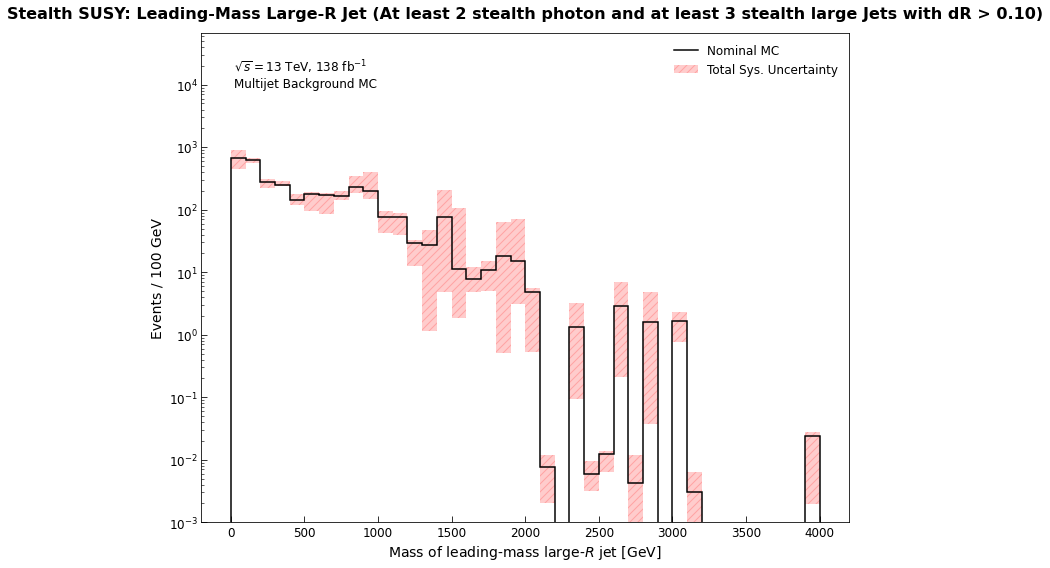

Total events loaded: 590
Expected events loaded: 87527.32978734953
Calculating uncertainty envelope across 26 systematic variations...

--- Event Yields & Uncertainties per Bin ---
Bin    0 -  100 GeV:   648.79 events | Stat: ±100.07 | Sys: +221.03 / -205.19
Bin  100 -  200 GeV:   604.91 events | Stat: ± 84.38 | Sys: + 63.15 / - 57.94
Bin  200 -  300 GeV:   277.74 events | Stat: ± 54.38 | Sys: + 31.22 / - 52.88
Bin  300 -  400 GeV:   238.14 events | Stat: ± 45.71 | Sys: + 44.27 / - 12.10
Bin  400 -  500 GeV:   143.33 events | Stat: ± 40.51 | Sys: + 35.47 / - 22.23
Bin  500 -  600 GeV:   181.36 events | Stat: ± 52.63 | Sys: + 12.94 / - 86.90
Bin  600 -  700 GeV:   170.32 events | Stat: ± 43.51 | Sys: + 12.89 / - 84.55
Bin  700 -  800 GeV:   166.95 events | Stat: ± 42.08 | Sys: + 34.95 / - 22.31
Bin  800 -  900 GeV:   226.89 events | Stat: ± 76.12 | Sys: +125.13 / - 40.79
Bin  900 - 1000 GeV:   197.85 events | Stat: ± 54.36 | Sys: +200.56 / - 48.80
Bin 1000 - 1100 GeV:    72.36 events | 

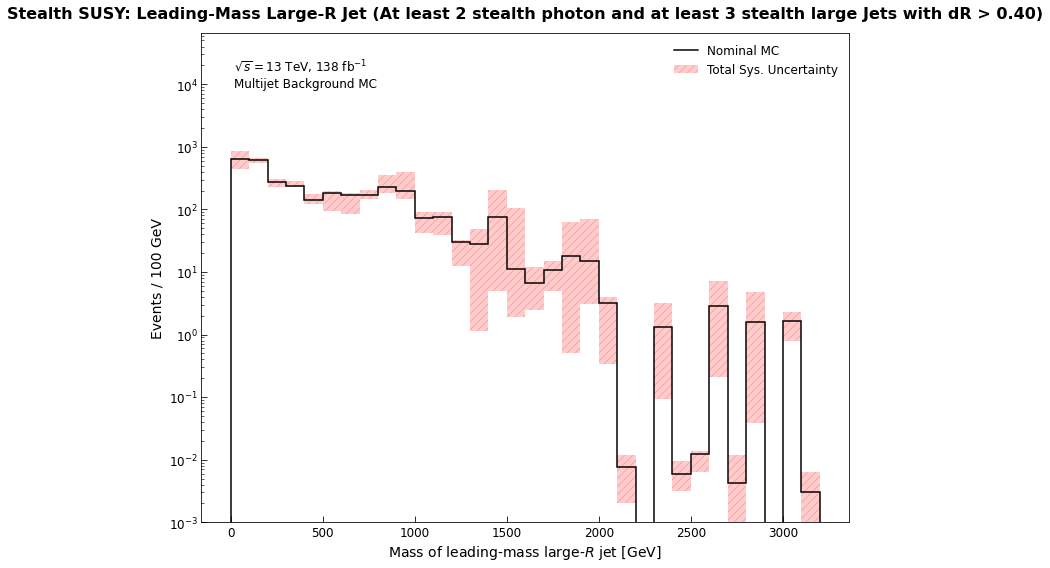

In [9]:
df_01 = load_region_data("MC_Events_JAlvarez_Final_MII/df_1sp_2slj_dR_0.10")
df_04 = load_region_data("MC_Events_JAlvarez_Final_MII/df_1sp_2slj_dR_0.40")

plot_dataframe(df_01, "At least 2 stealth photon and at least 3 stealth large Jets with dR > 0.10", "lead_mass_ljet_mass", 100)
plot_dataframe(df_04, "At least 2 stealth photon and at least 3 stealth large Jets with dR > 0.40", "lead_mass_ljet_mass", 100)